# EV01 Excavator Cell + VCU Analysis (Stage 1–5)
Robust version with correct column mapping

In [2]:

import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")


In [3]:

MASTER_ROOT = Path("data/analysis/master")  # change if needed
START_DATE = "2026-01-22"
END_DATE = "2026-03-08"
VEHICLE_ID = "EV01"


In [4]:

def load_master_dataset(start_date, end_date, vehicle_id, root):
    dates = pd.date_range(start_date, end_date, freq="D")
    paths = []
    for d in dates:
        p = root / f"dt={d.date()}" / f"vehicle_id={vehicle_id}.parquet"
        if p.exists():
            paths.append(p)

    if not paths:
        raise FileNotFoundError("No parquet partitions found.")

    df = pd.concat([pd.read_parquet(p) for p in paths], ignore_index=True)
    return df

df = load_master_dataset(START_DATE, END_DATE, VEHICLE_ID, MASTER_ROOT)
print(df.shape)


(744618, 68)


In [5]:

# Canonical mapping based on your schema
analysis_df = df.copy()

analysis_df["soc"] = analysis_df["soc_pct"]
analysis_df["current"] = analysis_df["battery_current_a"]
analysis_df["abs_current"] = analysis_df["battery_current_a"].abs()
analysis_df["cell_spread"] = analysis_df["max_cell_voltage_v"] - analysis_df["min_cell_voltage_v"]
analysis_df["pack_v_std"] = analysis_df["pack_voltage_std"]
analysis_df["temp_range"] = analysis_df["pack_temp_range"]
analysis_df["trip"] = analysis_df["trip_id"]
analysis_df["hottest_module"] = analysis_df["hottest_module_id"]

analysis_df["soc_band"] = pd.cut(
    analysis_df["soc"],
    bins=[0,20,40,60,80,100],
    labels=["0-20","20-40","40-60","60-80","80-100"]
)

analysis_df["current_direction"] = np.where(
    analysis_df["current"] > 0, "discharge", "charge"
)

analysis_df.head()


,timestamp,vehicle_id,trip_id,soc_pct,battery_current_a,stack_voltage_v,output_power_kw,max_cell_voltage_v,min_cell_voltage_v,avg_cell_voltage_v,...,operating_regime,is_clean,soc,current,abs_current,cell_spread,pack_v_std,temp_range,trip,hottest_module
0,2026-01-22 15:21:36,EV01,EV01_000833,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,idle,True,NaN,NaN,NaN,NaN,0.001164,NaN,EV01_000833,<NA>
1,2026-01-22 15:21:37,EV01,EV01_000833,72.0,13.0,590.775,7.680,NaN,NaN,NaN,...,light_discharge,True,72.0,13.0,13.0,NaN,0.001277,20.0,EV01_000833,1
2,2026-01-22 15:21:38,EV01,EV01_000833,72.0,11.0,590.815,6.499,NaN,NaN,NaN,...,light_discharge,True,72.0,11.0,11.0,NaN,0.001342,20.0,EV01_000833,1
3,2026-01-22 15:21:39,EV01,EV01_000833,72.0,13.0,590.798,7.680,NaN,NaN,NaN,...,light_discharge,True,72.0,13.0,13.0,NaN,0.006831,20.0,EV01_000833,1
4,2026-01-22 15:21:40,EV01,EV01_000833,72.0,13.0,590.841,7.681,NaN,NaN,NaN,...,light_discharge,True,72.0,13.0,13.0,NaN,0.005896,20.0,EV01_000833,1


## Distribution Analysis

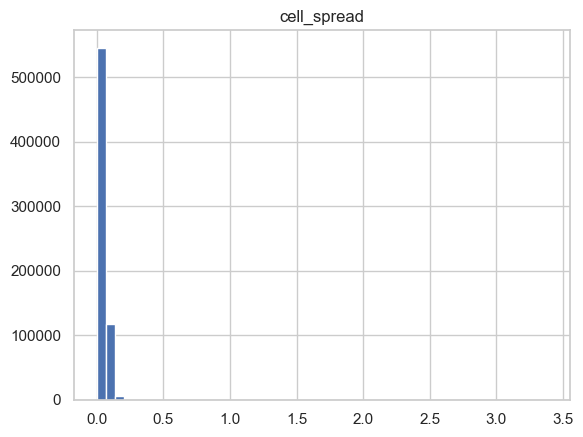

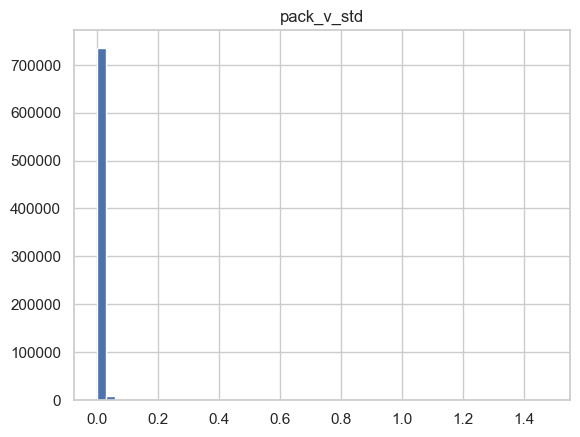

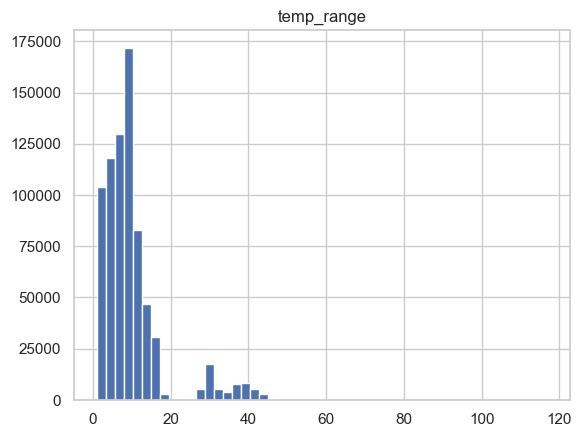

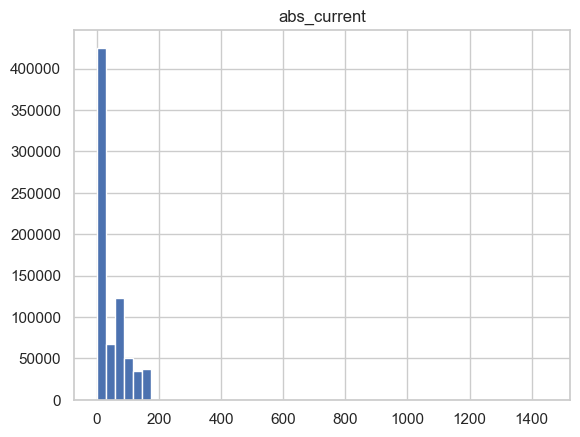

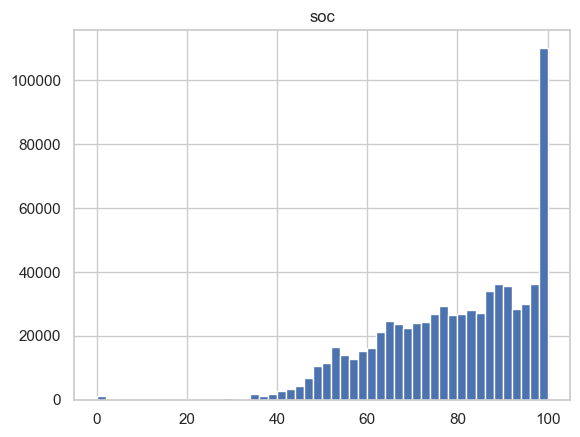

In [6]:

cols = ["cell_spread","pack_v_std","temp_range","abs_current","soc"]

for c in cols:
    plt.figure()
    analysis_df[c].hist(bins=50)
    plt.title(c)
    plt.show()


## Regime Segmentation

In [7]:

analysis_df.groupby(["soc_band","current_direction"])[
    ["cell_spread","temp_range","pack_v_std"]
].mean()


/var/folders/9c/b39n0d9s1gd9g3f3qpd1ghxc0000gn/T/ipykernel_54151/1125333515.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  analysis_df.groupby(["soc_band","current_direction"])[


cell_spread  temp_range  pack_v_std
soc_band current_direction                                     
0-20     charge                0.045991    1.553047    0.008005
         discharge             0.076971    4.556333    0.009844
20-40    charge                0.216901   10.500000    0.013042
         discharge             0.071936    9.446246    0.013385
40-60    charge                0.071523   14.084090    0.010068
         discharge             0.073119    9.593747    0.012047
60-80    charge                0.062987   11.291448    0.010548
         discharge             0.062507    8.709589    0.011271
80-100   charge                0.071021   10.952973    0.012932
         discharge             0.055520   10.024698    0.009978

## Weak Module Detection

In [8]:

analysis_df["hottest_module"].value_counts()


hottest_module
1    467841
3    145806
4     76797
2     48170
5      6003
Name: count, dtype: Int64

## Trip-Level Analysis

In [9]:

trip_stats = analysis_df.groupby("trip").agg({
    "cell_spread":"max",
    "temp_range":"max",
    "abs_current":"mean"
}).sort_values("cell_spread", ascending=False)

trip_stats.head(10)


,cell_spread,temp_range,abs_current
trip,,,
EV01_001019,3.385,9.0,6.618399
EV01_001088,3.326,53.0,34.654176
EV01_001135,3.324,15.0,23.959191
EV01_001180,3.320,11.0,26.392344
EV01_001137,3.320,9.0,9.193333
EV01_001268,3.320,11.0,47.580415
EV01_001140,3.319,53.0,22.552770
EV01_000901,3.318,60.0,68.550463
EV01_000860,3.317,39.0,26.911989


## Correlation Analysis

In [10]:

corr = analysis_df[
    ["cell_spread","temp_range","pack_v_std","abs_current","soc"]
].corr()

corr


,cell_spread,temp_range,pack_v_std,abs_current,soc
cell_spread,1.000000,-0.015696,0.139421,-0.024465,-0.053121
temp_range,-0.015696,1.000000,-0.186562,0.052167,0.059029
pack_v_std,0.139421,-0.186562,1.000000,-0.025585,-0.053409
abs_current,-0.024465,0.052167,-0.025585,1.000000,-0.102292
soc,-0.053121,0.059029,-0.053409,-0.102292,1.000000


In [13]:
# Extreme spread rows: safe column selection
extreme_spread = analysis_df[analysis_df["cell_spread"] > 1].copy()

print("Extreme spread rows:", len(extreme_spread))

cols_to_show = [
    "timestamp", "vehicle_id", "trip", "soc", "current", "abs_current",
    "cell_spread", "pack_v_std", "temp_range", "hottest_module",
    "max_cell_voltage_v", "min_cell_voltage_v", "battery_status",
    "fault_any", "cell_quality_flag"  # <-- fixed here
]

# keep only columns that actually exist
cols_to_show = [c for c in cols_to_show if c in extreme_spread.columns]

display(
    extreme_spread[cols_to_show]
    .sort_values(["cell_spread", "timestamp"], ascending=[False, True])
    .head(50)
)

Extreme spread rows: 667


,timestamp,vehicle_id,trip,soc,current,abs_current,cell_spread,pack_v_std,temp_range,hottest_module,max_cell_voltage_v,min_cell_voltage_v,battery_status,fault_any,cell_quality_flag
408512,2026-02-16 02:27:30,EV01,EV01_001019,98.0,63.0,63.0,3.385,0.011140,5.0,1,3.385,0.0,Charging,0,32
408513,2026-02-16 02:27:32,EV01,EV01_001019,98.0,62.0,62.0,3.385,0.011197,5.0,1,3.385,0.0,Charging,0,32
408514,2026-02-16 02:27:34,EV01,EV01_001019,98.0,62.0,62.0,3.385,0.011108,5.0,1,3.385,0.0,Charging,0,32
408515,2026-02-16 02:27:36,EV01,EV01_001019,98.0,62.0,62.0,3.385,0.011125,5.0,1,3.385,0.0,Charging,0,32
408516,2026-02-16 02:27:38,EV01,EV01_001019,98.0,62.0,62.0,3.385,0.011125,5.0,1,3.385,0.0,Charging,0,32
408517,2026-02-16 02:27:40,EV01,EV01_001019,98.0,62.0,62.0,3.385,0.011124,5.0,1,3.385,0.0,Charging,0,32
408518,2026-02-16 02:27:42,EV01,EV01_001019,98.0,63.0,63.0,3.385,0.011123,5.0,1,3.385,0.0,Charging,0,32
408519,2026-02-16 02:27:44,EV01,EV01_001019,98.0,63.0,63.0,3.385,0.011143,5.0,1,3.385,0.0,Charging,0,32
408520,2026-02-16 02:27:46,EV01,EV01_001019,98.0,63.0,63.0,3.385,0.011127,5.0,1,3.385,0.0,Charging,0,32
408521,2026-02-16 02:27:48,EV01,EV01_001019,98.0,63.0,63.0,3.385,0.011136,5.0,1,3.385,0.0,Charging,0,32


In [14]:
extreme_trip_counts = (
    extreme_spread.groupby("trip")
    .size()
    .sort_values(ascending=False)
    .rename("n_extreme_rows")
    .reset_index()
)

display(extreme_trip_counts.head(20))

,trip,n_extreme_rows
0,EV01_001254,103
1,EV01_000860,93
2,EV01_001180,91
3,EV01_001248,86
4,EV01_000838,66
5,EV01_001264,61
6,EV01_001019,48
7,EV01_000889,26
8,EV01_001102,24
9,EV01_001088,21


Worst trips: ['EV01_001019', 'EV01_001088', 'EV01_001135']


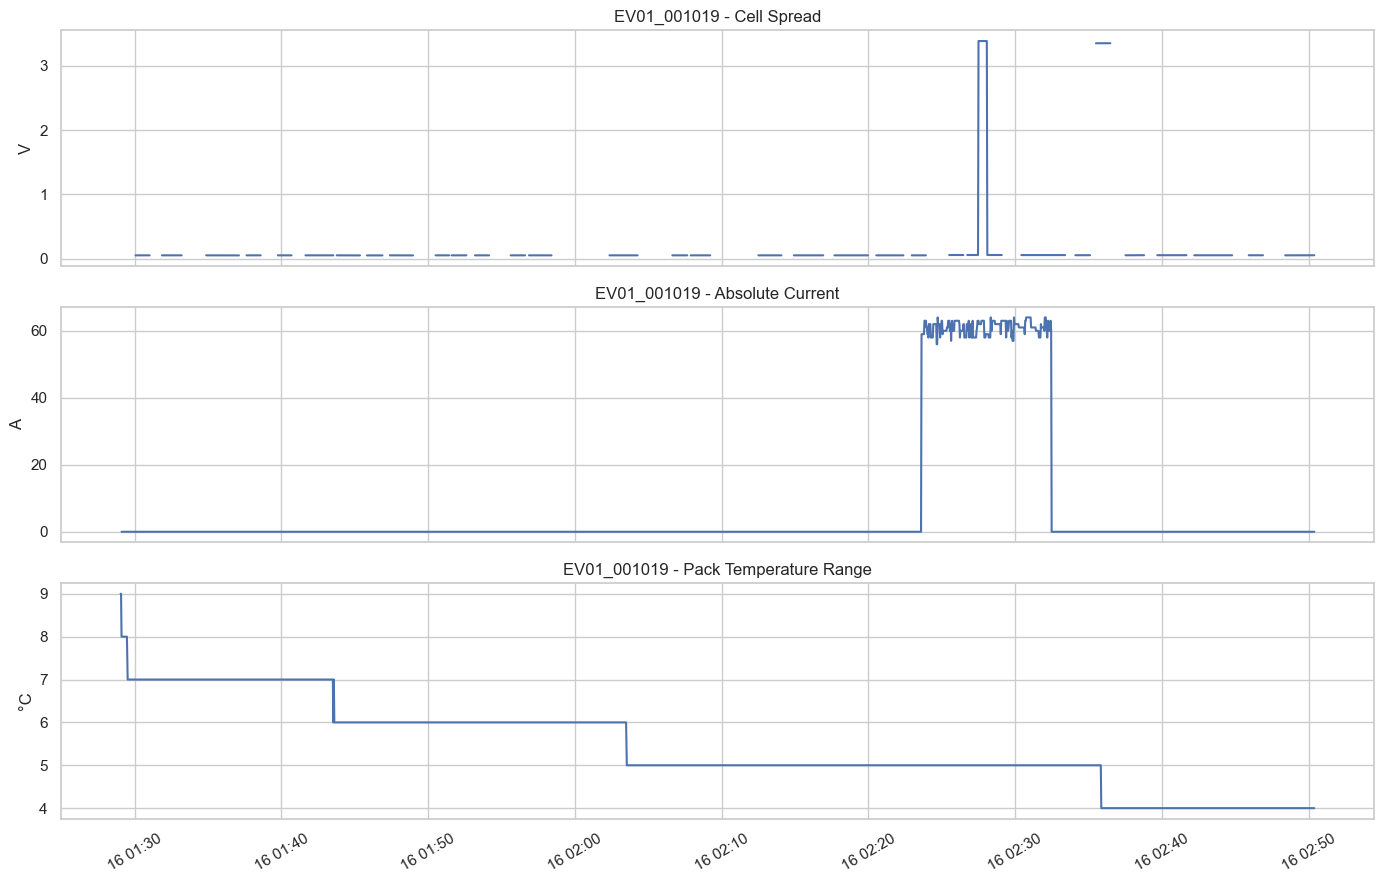

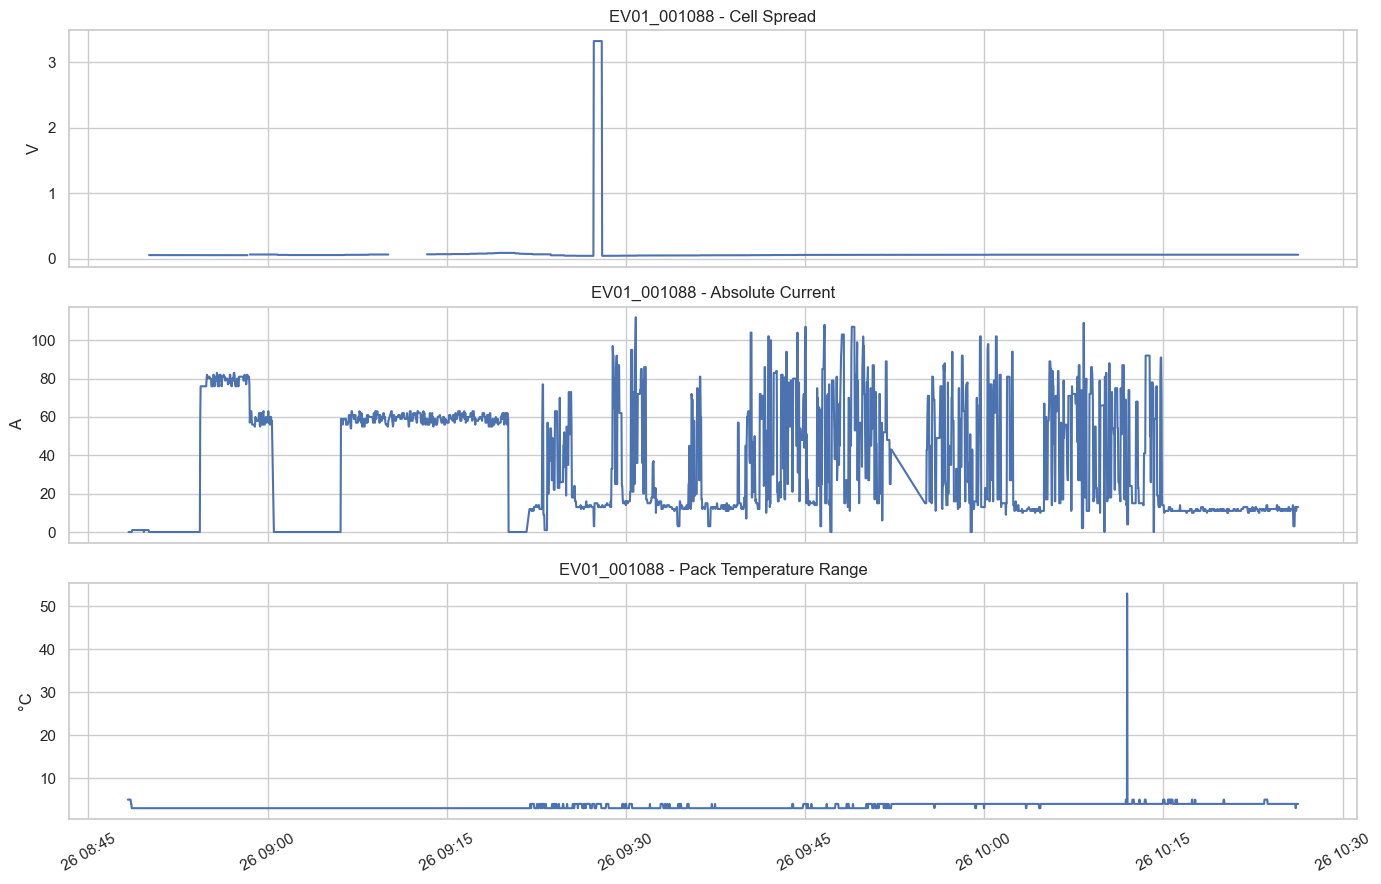

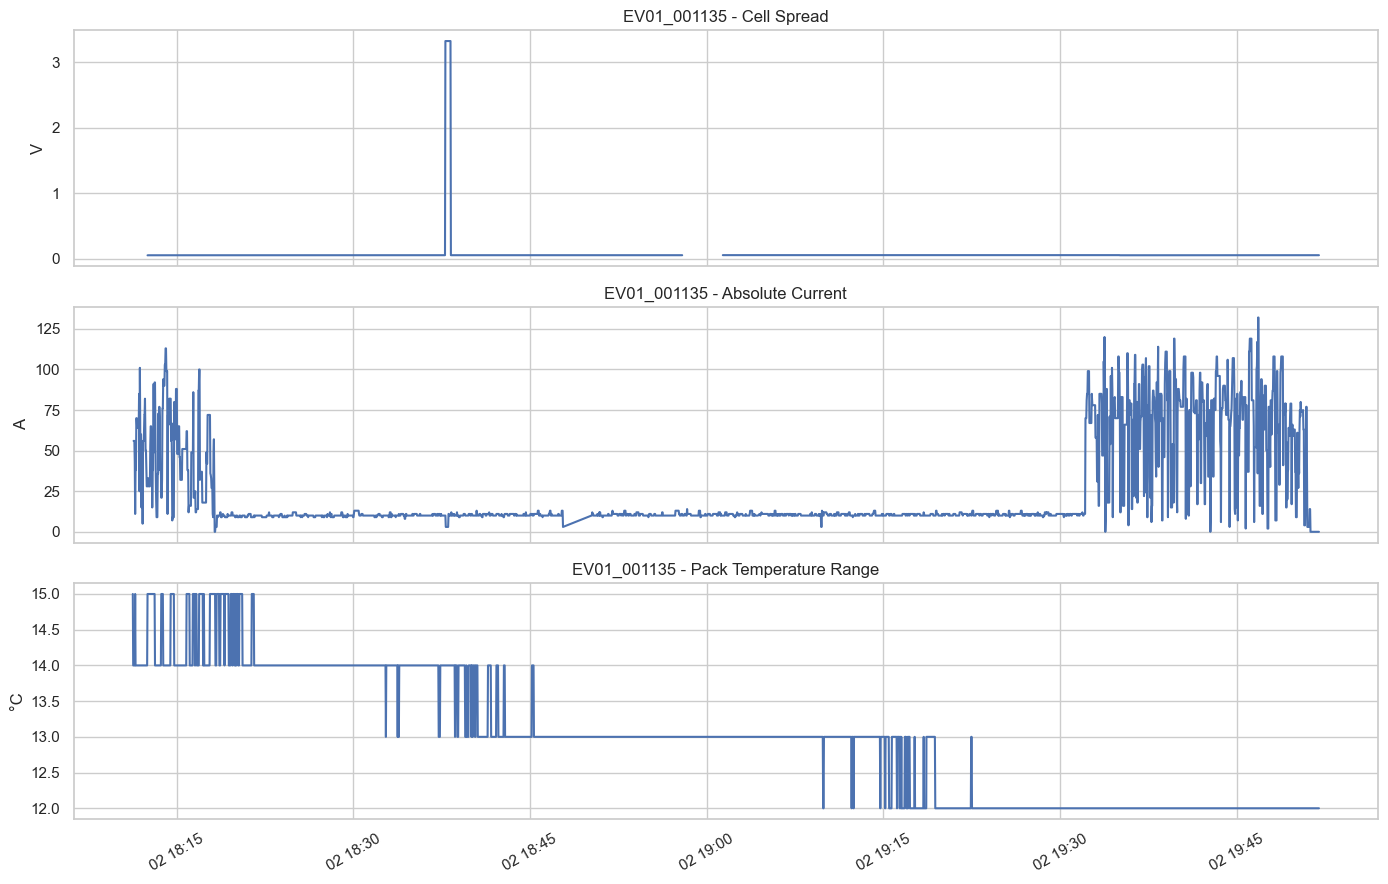

In [15]:
worst_trips = trip_stats.head(3).index.tolist()
print("Worst trips:", worst_trips)

for trip_id in worst_trips:
    x = analysis_df[analysis_df["trip"] == trip_id].sort_values("timestamp").copy()
    if x.empty:
        continue

    fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

    axes[0].plot(x["timestamp"], x["cell_spread"])
    axes[0].set_title(f"{trip_id} - Cell Spread")
    axes[0].set_ylabel("V")

    axes[1].plot(x["timestamp"], x["abs_current"])
    axes[1].set_title(f"{trip_id} - Absolute Current")
    axes[1].set_ylabel("A")

    axes[2].plot(x["timestamp"], x["temp_range"])
    axes[2].set_title(f"{trip_id} - Pack Temperature Range")
    axes[2].set_ylabel("°C")

    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

In [16]:
module_voltage_cols = [f"module_{i}_voltage_mean" for i in range(1, 6)]
module_temp_cols = [f"module_{i}_temp_mean" for i in range(1, 6)]

# Which module has lowest mean voltage in each row?
analysis_df["lowest_voltage_module"] = (
    analysis_df[module_voltage_cols]
    .idxmin(axis=1)
    .str.extract(r"module_(\d+)_")[0]
    .astype("Int64")
)

# Which module has highest mean temperature in each row?
analysis_df["highest_temp_module_from_means"] = (
    analysis_df[module_temp_cols]
    .idxmax(axis=1)
    .str.extract(r"module_(\d+)_")[0]
    .astype("Int64")
)

print("Lowest-voltage module frequency")
display(analysis_df["lowest_voltage_module"].value_counts(dropna=False).sort_index())

print("Highest-temp module frequency (from module temp means)")
display(analysis_df["highest_temp_module_from_means"].value_counts(dropna=False).sort_index())

/var/folders/9c/b39n0d9s1gd9g3f3qpd1ghxc0000gn/T/ipykernel_54151/721241672.py:7: FutureWarning: The behavior of DataFrame.idxmin with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  .idxmin(axis=1)
/var/folders/9c/b39n0d9s1gd9g3f3qpd1ghxc0000gn/T/ipykernel_54151/721241672.py:15: FutureWarning: The behavior of DataFrame.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  .idxmax(axis=1)


Lowest-voltage module frequency


lowest_voltage_module
1       228556
2       119408
3       147841
4       113055
5       135754
<NA>         4
Name: count, dtype: Int64

Highest-temp module frequency (from module temp means)


highest_temp_module_from_means
1       467841
2        48170
3       145806
4        76797
5         6003
<NA>         1
Name: count, dtype: Int64

In [17]:
module_cross = pd.crosstab(
    analysis_df["hottest_module"],
    analysis_df["lowest_voltage_module"],
    rownames=["hottest_module"],
    colnames=["lowest_voltage_module"],
    dropna=False,
)

display(module_cross)

lowest_voltage_module,1,2,3,4,5,<NA>
hottest_module,,,,,,
1,165414,66190,84781,64291,87161,4
2,14405,7449,9681,7277,9358,0
3,30839,29205,34781,26152,24829,0
4,16103,15486,17471,14279,13458,0
5,1795,1078,1127,1055,948,0
<NA>,0,0,0,1,0,0


In [18]:
module_summary = []

for i in range(1, 6):
    module_summary.append({
        "module": i,
        "mean_voltage_mean": analysis_df[f"module_{i}_voltage_mean"].mean(),
        "mean_voltage_std": analysis_df[f"module_{i}_voltage_std"].mean(),
        "mean_voltage_range": analysis_df[f"module_{i}_voltage_range"].mean(),
        "mean_temp_mean": analysis_df[f"module_{i}_temp_mean"].mean(),
        "mean_temp_range": analysis_df[f"module_{i}_temp_range"].mean(),
        "times_lowest_voltage_module": (analysis_df["lowest_voltage_module"] == i).sum(),
        "times_hottest_module": (analysis_df["hottest_module"] == i).sum(),
    })

module_summary = pd.DataFrame(module_summary).sort_values("module")
display(module_summary)

,module,mean_voltage_mean,mean_voltage_std,mean_voltage_range,mean_temp_mean,mean_temp_range,times_lowest_voltage_module,times_hottest_module
0,1,3.319957,0.011939,0.059974,32.700341,8.091975,228556,467841
1,2,3.320398,0.010388,0.050859,32.173031,8.767895,119408,48170
2,3,3.320318,0.010339,0.050731,32.451123,7.346018,147841,145806
3,4,3.320423,0.010437,0.051003,32.289613,7.356832,113055,76797
4,5,3.320395,0.010375,0.050852,31.859249,7.205585,135754,6003


Rows in 20-40 charge slice: 2114


count    1929.000000
mean        0.216901
std         0.664971
min         0.060000
50%         0.072000
90%         0.091000
95%         0.111000
99%         3.294000
max         3.294000
Name: cell_spread, dtype: float64

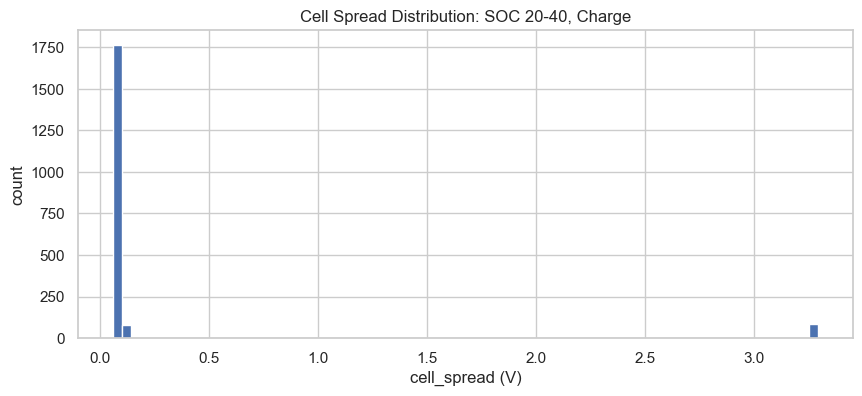

In [19]:
charge_20_40 = analysis_df[
    (analysis_df["soc_band"].astype(str) == "20-40") &
    (analysis_df["current_direction"] == "charge")
].copy()

print("Rows in 20-40 charge slice:", len(charge_20_40))
display(charge_20_40["cell_spread"].describe(percentiles=[0.5, 0.9, 0.95, 0.99]))

plt.figure(figsize=(10, 4))
charge_20_40["cell_spread"].hist(bins=80)
plt.title("Cell Spread Distribution: SOC 20-40, Charge")
plt.xlabel("cell_spread (V)")
plt.ylabel("count")
plt.show()

In [20]:
charge_20_40_trip = (
    charge_20_40.groupby("trip")
    .agg(
        n_rows=("cell_spread", "size"),
        mean_spread=("cell_spread", "mean"),
        max_spread=("cell_spread", "max"),
        mean_abs_current=("abs_current", "mean"),
        mean_temp_range=("temp_range", "mean"),
    )
    .sort_values(["max_spread", "mean_spread"], ascending=False)
)

display(charge_20_40_trip.head(20))

,n_rows,mean_spread,max_spread,mean_abs_current,mean_temp_range
trip,,,,,
EV01_001248,942,0.417320,3.294,0.0,6.118896
EV01_000987,89,0.109818,0.111,0.0,5.000000
EV01_001256,52,0.100100,0.105,0.0,1.019231
EV01_001271,148,0.090980,0.091,0.0,1.006757
EV01_001240,163,0.079681,0.081,0.0,2.000000
EV01_001270,29,0.076448,0.077,0.0,2.724138
EV01_001247,240,0.072146,0.074,0.0,11.004167
EV01_000871,451,0.060197,0.061,0.0,28.248337


In [21]:
analysis_df["current_bin"] = pd.qcut(
    analysis_df["abs_current"].rank(method="first"),
    q=5,
    labels=["Q1_low", "Q2", "Q3", "Q4", "Q5_high"]
)

current_soc_grid = (
    analysis_df.groupby(["soc_band", "current_bin"], observed=False)
    .agg(
        mean_spread=("cell_spread", "mean"),
        p95_spread=("cell_spread", lambda s: s.quantile(0.95)),
        mean_temp_range=("temp_range", "mean"),
        n=("cell_spread", "size"),
    )
    .reset_index()
)

display(current_soc_grid)

,soc_band,current_bin,mean_spread,p95_spread,mean_temp_range,n
0,0-20,Q1_low,0.045991,0.052,1.532880,441
1,0-20,Q2,NaN,NaN,NaN,0
2,0-20,Q3,NaN,NaN,NaN,0
3,0-20,Q4,0.051000,0.051,2.000000,1
4,0-20,Q5_high,0.076989,0.118,4.558123,1428
5,20-40,Q1_low,0.211368,0.111,10.360708,2204
6,20-40,Q2,0.074369,0.109,12.957895,475
7,20-40,Q3,0.080458,0.109,13.281951,1025
8,20-40,Q4,0.080445,0.107,6.260496,1048
9,20-40,Q5_high,0.064335,0.105,8.595745,2350


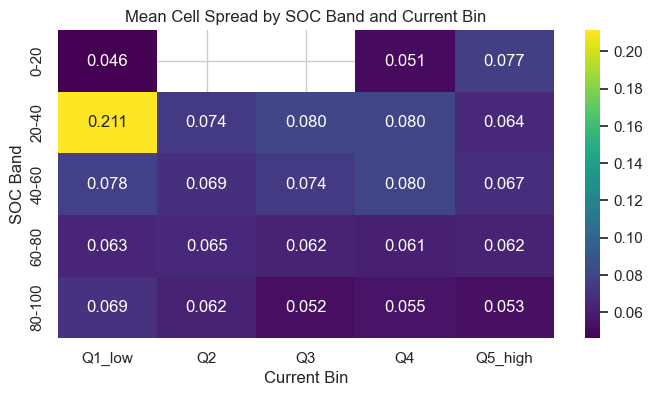

In [22]:
pivot_mean_spread = current_soc_grid.pivot(
    index="soc_band", columns="current_bin", values="mean_spread"
)

plt.figure(figsize=(8, 4))
sns.heatmap(pivot_mean_spread, annot=True, fmt=".3f", cmap="viridis")
plt.title("Mean Cell Spread by SOC Band and Current Bin")
plt.xlabel("Current Bin")
plt.ylabel("SOC Band")
plt.show()

In [23]:
analysis_df["date"] = pd.to_datetime(analysis_df["timestamp"]).dt.date

daily_summary = (
    analysis_df.groupby("date")
    .agg(
        mean_spread=("cell_spread", "mean"),
        p95_spread=("cell_spread", lambda s: s.quantile(0.95)),
        max_spread=("cell_spread", "max"),
        mean_temp_range=("temp_range", "mean"),
        max_temp_range=("temp_range", "max"),
        mean_abs_current=("abs_current", "mean"),
        n_rows=("cell_spread", "size"),
    )
    .sort_index()
)

display(daily_summary.head())
display(daily_summary.sort_values("max_spread", ascending=False).head(10))

,mean_spread,p95_spread,max_spread,mean_temp_range,max_temp_range,mean_abs_current,n_rows
date,,,,,,,
2026-01-22,0.058160,0.129,0.241,38.704116,47.0,40.191718,6196
2026-01-23,0.053149,0.059,3.296,35.050755,113.0,41.961638,13516
2026-01-24,0.044051,0.058,3.292,32.485968,60.0,50.438019,12186
2026-01-25,0.043178,0.058,0.058,31.130435,37.0,2.009346,230
2026-01-26,0.061018,0.053,3.317,30.206460,60.0,19.411957,12569


,mean_spread,p95_spread,max_spread,mean_temp_range,max_temp_range,mean_abs_current,n_rows
date,,,,,,,
2026-02-16,0.100569,0.109,3.385,4.110963,53.0,38.507525,6002
2026-02-26,0.063976,0.074,3.326,6.186783,53.0,44.479165,23198
2026-03-02,0.066590,0.102,3.324,9.528195,17.0,40.962878,26742
2026-02-10,0.064997,0.141,3.320,7.722647,29.0,43.656511,34548
2026-03-06,0.083994,0.128,3.320,9.313753,33.0,38.658904,26779
2026-03-03,0.066949,0.085,3.319,8.497295,53.0,44.305357,25876
2026-01-31,0.053314,0.111,3.318,7.812402,60.0,69.076566,8305
2026-01-26,0.061018,0.053,3.317,30.206460,60.0,19.411957,12569
2026-02-27,0.065175,0.076,3.308,6.467134,53.0,49.184149,19245


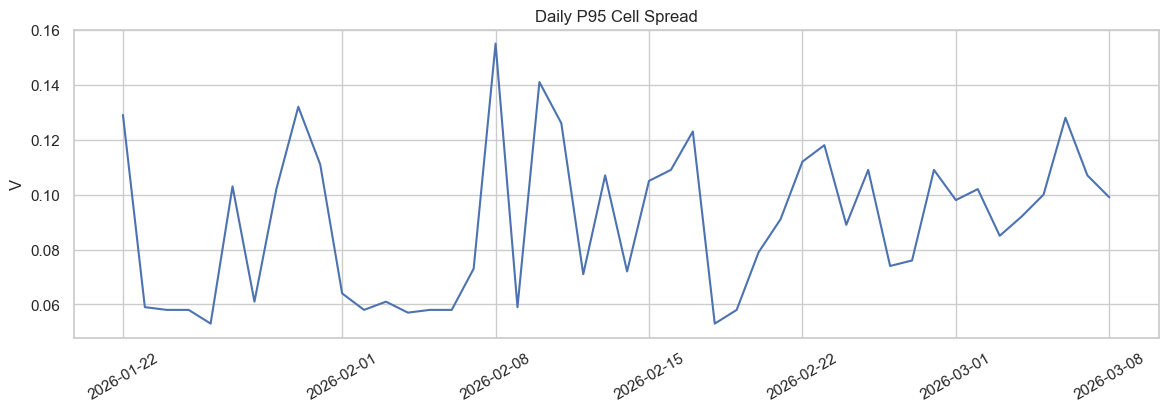

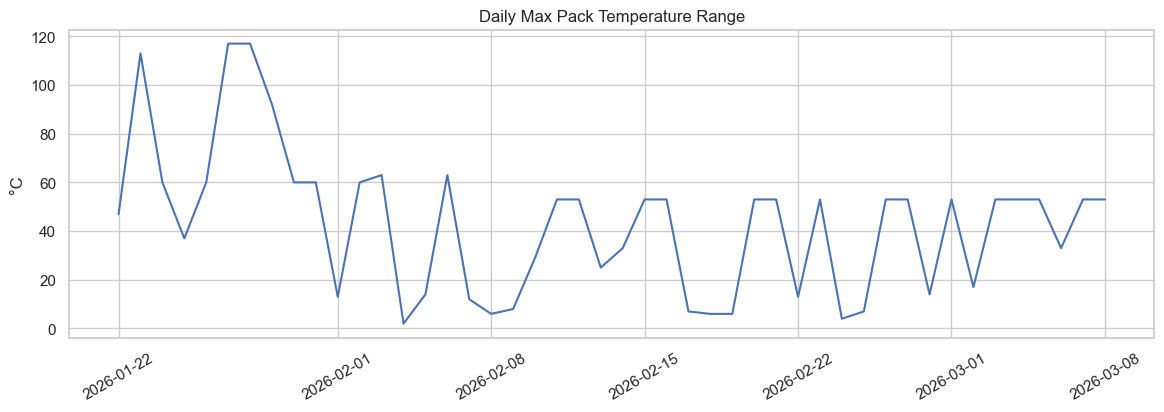

In [24]:
plt.figure(figsize=(14, 4))
plt.plot(daily_summary.index, daily_summary["p95_spread"])
plt.xticks(rotation=30)
plt.title("Daily P95 Cell Spread")
plt.ylabel("V")
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(daily_summary.index, daily_summary["max_temp_range"])
plt.xticks(rotation=30)
plt.title("Daily Max Pack Temperature Range")
plt.ylabel("°C")
plt.show()

In [25]:
candidate_events = analysis_df[
    (
        (analysis_df["soc"] <= 20) &
        (analysis_df["current_direction"] == "discharge") &
        (analysis_df["cell_spread"] >= analysis_df["cell_spread"].quantile(0.95))
    )
    |
    (
        (analysis_df["soc_band"].astype(str) == "20-40") &
        (analysis_df["current_direction"] == "charge") &
        (analysis_df["cell_spread"] >= analysis_df["cell_spread"].quantile(0.95))
    )
    |
    (
        analysis_df["temp_range"] >= analysis_df["temp_range"].quantile(0.95)
    )
].copy()

print("Candidate event rows:", len(candidate_events))
display(
    candidate_events[
        [
            "timestamp", "trip", "soc", "current", "abs_current",
            "cell_spread", "pack_v_std", "temp_range", "hottest_module",
            "lowest_voltage_module", "fault_any"
        ]
    ].sort_values(["cell_spread", "temp_range"], ascending=False).head(50)
)

Candidate event rows: 40296


,timestamp,trip,soc,current,abs_current,cell_spread,pack_v_std,temp_range,hottest_module,lowest_voltage_module,fault_any
33785,2026-01-26 17:10:33,EV01_000860,91.0,11.0,11.0,3.317,0.001702,32.0,1,5,0
33823,2026-01-26 17:11:43,EV01_000860,91.0,14.0,14.0,3.317,0.001669,32.0,1,5,0
33824,2026-01-26 17:11:46,EV01_000860,91.0,13.0,13.0,3.317,0.001712,32.0,1,5,0
33825,2026-01-26 17:11:48,EV01_000860,91.0,13.0,13.0,3.317,0.001696,32.0,1,5,0
33826,2026-01-26 17:11:50,EV01_000860,91.0,10.0,10.0,3.317,0.001696,32.0,1,5,0
33827,2026-01-26 17:11:52,EV01_000860,91.0,10.0,10.0,3.317,0.001685,32.0,1,5,0
33828,2026-01-26 17:11:55,EV01_000860,91.0,13.0,13.0,3.317,0.001641,32.0,1,5,0
33829,2026-01-26 17:11:56,EV01_000860,91.0,13.0,13.0,3.317,0.001631,32.0,1,4,0
33830,2026-01-26 17:11:58,EV01_000860,91.0,13.0,13.0,3.317,0.001627,32.0,1,5,0
33831,2026-01-26 17:12:00,EV01_000860,91.0,13.0,13.0,3.317,0.001626,32.0,1,5,0


In [26]:
display(candidate_events["hottest_module"].value_counts(dropna=False).sort_index())
display(candidate_events["lowest_voltage_module"].value_counts(dropna=False).sort_index())

hottest_module
1    40076
2      107
3       93
4       13
5        7
Name: count, dtype: Int64

lowest_voltage_module
1    26439
2      815
3     1595
4     3672
5     7775
Name: count, dtype: Int64

In [27]:
# Likely artifact rows: one cell reported as zero while rest of pack looks normal
analysis_df["is_artifact_spread"] = (
    (analysis_df["min_cell_voltage_v"] <= 0.05) &
    (analysis_df["max_cell_voltage_v"] >= 3.0) &
    (analysis_df["cell_spread"] >= 1.0)
)

print("Artifact rows:", analysis_df["is_artifact_spread"].sum())
print("Artifact fraction:", analysis_df["is_artifact_spread"].mean())

Artifact rows: 667
Artifact fraction: 0.0008957613165408303


In [28]:
analysis_phys = analysis_df.loc[~analysis_df["is_artifact_spread"]].copy()

print("Original shape:", analysis_df.shape)
print("Physics-clean shape:", analysis_phys.shape)

print("Max cell_spread before:", analysis_df["cell_spread"].max())
print("Max cell_spread after:", analysis_phys["cell_spread"].max())

Original shape: (744618, 81)
Physics-clean shape: (743951, 81)
Max cell_spread before: 3.385
Max cell_spread after: 0.6000000000000001


In [29]:
regime_summary_clean = (
    analysis_phys.groupby(["soc_band", "current_direction"], observed=False)
    .agg(
        mean_spread=("cell_spread", "mean"),
        p95_spread=("cell_spread", lambda s: s.quantile(0.95)),
        max_spread=("cell_spread", "max"),
        mean_temp_range=("temp_range", "mean"),
        p95_temp_range=("temp_range", lambda s: s.quantile(0.95)),
        mean_pack_v_std=("pack_v_std", "mean"),
        n=("cell_spread", "size"),
    )
)

display(regime_summary_clean)

mean_spread  p95_spread  max_spread  \
soc_band current_direction                                        
0-20     charge                0.045991       0.052       0.052   
         discharge             0.076971       0.118       0.149   
20-40    charge                0.073314       0.092       0.111   
         discharge             0.071936       0.108       0.111   
40-60    charge                0.057945       0.110       0.133   
         discharge             0.067862       0.108       0.375   
60-80    charge                0.062987       0.098       0.127   
         discharge             0.061304       0.089       0.128   
80-100   charge                0.068568       0.148       0.600   
         discharge             0.052393       0.069       0.241   

                            mean_temp_range  p95_temp_range  mean_pack_v_std  \
soc_band current_direction                                                     
0-20     charge                    1.553047             2.0         0.008005   
         discharge                 4.556333            10.0         0.009844   
20-40    charge                   10.733235            28.0         0.013012   
         discharge                 9.446246            30.0         0.013385   
40-60    charge                   14.129365            35.0         0.010068   
         discharge                 9.598586            29.0         0.012048   
60-80    charge                   11.291448            39.0         0.010548   
         discharge                 8.702534            28.0         0.011273   
80-100   charge                   10.957280            38.0         0.012934   
         discharge                10.019808            30.0         0.009980   

                                 n  
soc_band current_direction          
0-20     charge                443  
         discharge            1429  
20-40    charge               2028  
         discharge            4995  
40-60    charge              14146  
         discharge           90667  
60-80    charge              25164  
         discharge          219252  
80-100   charge              67790  
         discharge          311293

In [30]:
trip_stats_clean = (
    analysis_phys.groupby("trip")
    .agg(
        max_spread=("cell_spread", "max"),
        p95_spread=("cell_spread", lambda s: s.quantile(0.95)),
        mean_spread=("cell_spread", "mean"),
        max_temp_range=("temp_range", "max"),
        mean_temp_range=("temp_range", "mean"),
        mean_abs_current=("abs_current", "mean"),
        n=("cell_spread", "size"),
    )
    .sort_values(["max_spread", "p95_spread"], ascending=False)
)

display(trip_stats_clean.head(20))

,max_spread,p95_spread,mean_spread,max_temp_range,mean_temp_range,mean_abs_current,n
trip,,,,,,,
EV01_000988,0.600,0.600,0.122678,11.0,7.755824,14.073387,4464
EV01_000871,0.600,0.061,0.072798,45.0,28.328174,0.000000,5104
EV01_000894,0.375,0.240,0.123427,5.0,2.937816,35.325217,4149
EV01_000837,0.241,0.129,0.060322,47.0,38.810141,43.488451,3550
EV01_001251,0.219,0.119,0.043979,8.0,6.613879,36.010745,4496
EV01_001080,0.201,0.135,0.069755,7.0,6.173711,23.923974,2153
EV01_000903,0.196,0.170,0.096297,9.0,8.213198,41.707192,591
EV01_000851,0.187,0.097,0.043616,43.0,39.408660,82.209433,3903
EV01_000895,0.177,0.118,0.050009,18.0,15.142879,96.937532,6481


In [31]:
daily_summary_clean = (
    analysis_phys.groupby("date")
    .agg(
        mean_spread=("cell_spread", "mean"),
        p95_spread=("cell_spread", lambda s: s.quantile(0.95)),
        max_spread=("cell_spread", "max"),
        mean_temp_range=("temp_range", "mean"),
        max_temp_range=("temp_range", "max"),
        mean_abs_current=("abs_current", "mean"),
        n_rows=("cell_spread", "size"),
    )
    .sort_index()
)

display(daily_summary_clean.sort_values("max_spread", ascending=False).head(15))

,mean_spread,p95_spread,max_spread,mean_temp_range,max_temp_range,mean_abs_current,n_rows
date,,,,,,,
2026-02-13,0.066518,0.107,0.600,6.902532,25.0,38.894089,24839
2026-01-28,0.059049,0.061,0.600,13.166851,117.0,9.342142,7234
2026-01-30,0.061502,0.132,0.375,9.337596,60.0,46.593747,23848
2026-01-22,0.058160,0.129,0.241,38.704116,47.0,40.191718,6196
2026-02-08,0.065198,0.140,0.219,4.439728,6.0,67.072035,3675
2026-02-23,0.069528,0.118,0.201,4.350351,53.0,46.258807,6973
2026-01-31,0.052502,0.111,0.196,7.812357,60.0,69.090585,8303
2026-01-24,0.042674,0.058,0.187,32.486988,60.0,50.424219,12181
2026-02-25,0.060153,0.109,0.177,2.769231,7.0,29.419146,4953


In [32]:
module_summary_clean = []

for i in range(1, 6):
    module_summary_clean.append({
        "module": i,
        "mean_voltage_mean": analysis_phys[f"module_{i}_voltage_mean"].mean(),
        "mean_voltage_std": analysis_phys[f"module_{i}_voltage_std"].mean(),
        "mean_voltage_range": analysis_phys[f"module_{i}_voltage_range"].mean(),
        "mean_temp_mean": analysis_phys[f"module_{i}_temp_mean"].mean(),
        "mean_temp_range": analysis_phys[f"module_{i}_temp_range"].mean(),
        "times_lowest_voltage_module": (analysis_phys["lowest_voltage_module"] == i).sum(),
        "times_hottest_module": (analysis_phys["hottest_module"] == i).sum(),
    })

module_summary_clean = pd.DataFrame(module_summary_clean)
display(module_summary_clean)

,module,mean_voltage_mean,mean_voltage_std,mean_voltage_range,mean_temp_mean,mean_temp_range,times_lowest_voltage_module,times_hottest_module
0,1,3.319976,0.011940,0.059979,32.702898,8.091847,228403,467455
1,2,3.320418,0.010389,0.050864,32.175663,8.766971,119333,48071
2,3,3.320338,0.010340,0.050736,32.453959,7.346813,147739,145707
3,4,3.320443,0.010438,0.051009,32.292307,7.357535,112923,76722
4,5,3.320415,0.010376,0.050857,31.861642,7.206307,135549,5995


In [33]:
n_clean = len(analysis_phys)

module_rates = module_summary_clean.copy()
module_rates["pct_lowest_voltage_module"] = 100 * module_rates["times_lowest_voltage_module"] / n_clean
module_rates["pct_hottest_module"] = 100 * module_rates["times_hottest_module"] / n_clean

display(
    module_rates[
        ["module", "pct_lowest_voltage_module", "pct_hottest_module",
         "mean_voltage_mean", "mean_temp_mean", "mean_temp_range"]
    ]
)

,module,pct_lowest_voltage_module,pct_hottest_module,mean_voltage_mean,mean_temp_mean,mean_temp_range
0,1,30.701350,62.834111,3.319976,32.702898,8.091847
1,2,16.040438,6.461581,3.320418,32.175663,8.766971
2,3,19.858700,19.585564,3.320338,32.453959,7.346813
3,4,15.178822,10.312776,3.320443,32.292307,7.357535
4,5,18.220152,0.805833,3.320415,31.861642,7.206307


In [34]:
module1_soc = (
    analysis_phys.assign(is_hot_mod1=analysis_phys["hottest_module"] == 1,
                         is_low_mod1=analysis_phys["lowest_voltage_module"] == 1)
    .groupby("soc_band", observed=False)
    .agg(
        pct_hot_mod1=("is_hot_mod1", "mean"),
        pct_low_mod1=("is_low_mod1", "mean"),
        mean_spread=("cell_spread", "mean"),
        p95_spread=("cell_spread", lambda s: s.quantile(0.95)),
        mean_temp_range=("temp_range", "mean"),
        n=("cell_spread", "size"),
    )
)

module1_soc["pct_hot_mod1"] *= 100
module1_soc["pct_low_mod1"] *= 100
display(module1_soc)

,pct_hot_mod1,pct_low_mod1,mean_spread,p95_spread,mean_temp_range,n
soc_band,,,,,,
0-20,46.848291,49.519231,0.069525,0.118,3.845620,1872
20-40,54.022498,31.942467,0.072336,0.107,9.817884,7023
40-60,63.659088,26.999513,0.066605,0.109,10.210079,104813
60-80,63.927484,31.781601,0.061474,0.091,8.969077,244416
80-100,62.679941,31.049137,0.055129,0.091,10.187452,379083


In [35]:
analysis_phys["current_bin"] = pd.qcut(
    analysis_phys["abs_current"].rank(method="first"),
    q=5,
    labels=["Q1_low", "Q2", "Q3", "Q4", "Q5_high"]
)

module1_current = (
    analysis_phys.assign(is_hot_mod1=analysis_phys["hottest_module"] == 1,
                         is_low_mod1=analysis_phys["lowest_voltage_module"] == 1)
    .groupby("current_bin", observed=False)
    .agg(
        pct_hot_mod1=("is_hot_mod1", "mean"),
        pct_low_mod1=("is_low_mod1", "mean"),
        mean_spread=("cell_spread", "mean"),
        p95_spread=("cell_spread", lambda s: s.quantile(0.95)),
        mean_temp_range=("temp_range", "mean"),
        n=("cell_spread", "size"),
    )
)

module1_current["pct_hot_mod1"] *= 100
module1_current["pct_low_mod1"] *= 100
display(module1_current)

,pct_hot_mod1,pct_low_mod1,mean_spread,p95_spread,mean_temp_range,n
current_bin,,,,,,
Q1_low,71.342519,40.956721,0.065340,0.127,10.953434,147253
Q2,54.054586,30.075653,0.060085,0.095,8.938385,147253
Q3,50.410518,25.039897,0.055354,0.086,8.093852,147253
Q4,66.292028,27.032386,0.056766,0.089,10.346282,147253
Q5_high,73.172024,30.751835,0.058154,0.089,10.491121,147253


In [36]:
stress_slice = analysis_phys[
    (analysis_phys["soc"] <= 20) &
    (analysis_phys["current_direction"] == "discharge") &
    (analysis_phys["abs_current"] >= analysis_phys["abs_current"].quantile(0.8))
].copy()

print("Stress slice rows:", len(stress_slice))

display(
    stress_slice.groupby("hottest_module")
    .agg(
        mean_spread=("cell_spread", "mean"),
        p95_spread=("cell_spread", lambda s: s.quantile(0.95)),
        mean_temp_range=("temp_range", "mean"),
        n=("cell_spread", "size"),
    )
    .sort_values("mean_spread", ascending=False)
)

display(
    stress_slice.groupby("lowest_voltage_module")
    .agg(
        mean_spread=("cell_spread", "mean"),
        p95_spread=("cell_spread", lambda s: s.quantile(0.95)),
        mean_temp_range=("temp_range", "mean"),
        n=("cell_spread", "size"),
    )
    .sort_values("mean_spread", ascending=False)
)

Stress slice rows: 1701


,mean_spread,p95_spread,mean_temp_range,n
hottest_module,,,,
1,0.091761,0.149,6.722557,829
5,0.057564,0.063,2.717949,39
2,0.057248,0.063,2.246061,825
3,0.051250,0.053,1.500000,4
4,0.051000,0.054,1.500000,4


,mean_spread,p95_spread,mean_temp_range,n
lowest_voltage_module,,,,
1,0.093213,0.149,6.850856,818
3,0.056620,0.063,2.145299,351
2,0.056075,0.063,2.079812,213
4,0.055872,0.063,2.352941,187
5,0.055636,0.063,2.303030,132


In [37]:
charge_20_40_clean = analysis_phys[
    (analysis_phys["soc_band"].astype(str) == "20-40") &
    (analysis_phys["current_direction"] == "charge")
].copy()

print("Rows:", len(charge_20_40_clean))
display(charge_20_40_clean["cell_spread"].describe(percentiles=[0.5, 0.9, 0.95, 0.99]))

charge_20_40_trip_clean = (
    charge_20_40_clean.groupby("trip")
    .agg(
        n_rows=("cell_spread", "size"),
        mean_spread=("cell_spread", "mean"),
        p95_spread=("cell_spread", lambda s: s.quantile(0.95)),
        max_spread=("cell_spread", "max"),
        mean_abs_current=("abs_current", "mean"),
        mean_temp_range=("temp_range", "mean"),
    )
    .sort_values(["mean_spread", "max_spread"], ascending=False)
)

display(charge_20_40_trip_clean.head(20))

Rows: 2028


count    1843.000000
mean        0.073314
std         0.011500
min         0.060000
50%         0.072000
90%         0.091000
95%         0.092000
99%         0.111000
max         0.111000
Name: cell_spread, dtype: float64

,n_rows,mean_spread,p95_spread,max_spread,mean_abs_current,mean_temp_range
trip,,,,,,
EV01_000987,89,0.109818,0.111,0.111,0.0,5.000000
EV01_001256,52,0.100100,0.105,0.105,0.0,1.019231
EV01_001271,148,0.090980,0.091,0.091,0.0,1.006757
EV01_001240,163,0.079681,0.080,0.081,0.0,2.000000
EV01_001270,29,0.076448,0.077,0.077,0.0,2.724138
EV01_001248,856,0.072279,0.073,0.073,0.0,6.231308
EV01_001247,240,0.072146,0.074,0.074,0.0,11.004167
EV01_000871,451,0.060197,0.061,0.061,0.0,28.248337


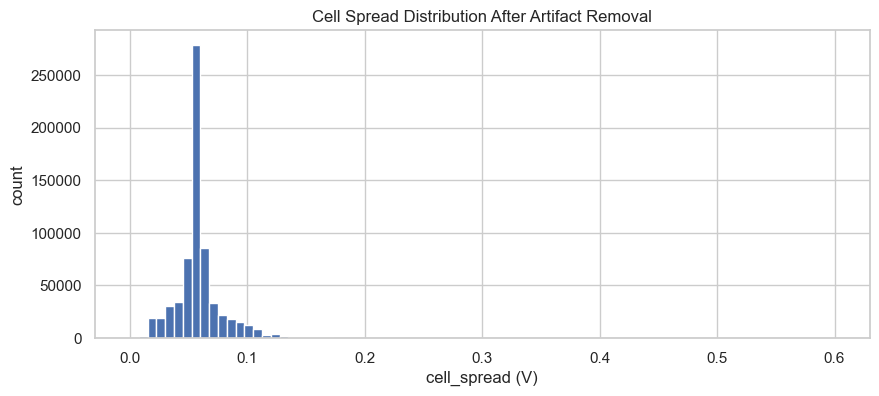

count    669389.000000
mean          0.059141
std           0.023759
min           0.000000
50%           0.057000
90%           0.083000
95%           0.099000
99%           0.134000
max           0.600000
Name: cell_spread, dtype: float64


In [38]:
plt.figure(figsize=(10, 4))
analysis_phys["cell_spread"].hist(bins=80)
plt.title("Cell Spread Distribution After Artifact Removal")
plt.xlabel("cell_spread (V)")
plt.ylabel("count")
plt.show()

print(analysis_phys["cell_spread"].describe(percentiles=[0.5, 0.9, 0.95, 0.99]))

In [39]:
# Excavator working-load slice:
# discharge + top 30% current + not artifacts
work_current_thr = analysis_phys["abs_current"].quantile(0.70)

working_load = analysis_phys[
    (analysis_phys["current_direction"] == "discharge") &
    (analysis_phys["abs_current"] >= work_current_thr)
].copy()

print("Working-load threshold:", work_current_thr)
print("Working-load rows:", len(working_load))

display(
    working_load[["soc", "abs_current", "cell_spread", "temp_range", "hottest_module", "lowest_voltage_module"]]
    .describe()
)

Working-load threshold: 61.0
Working-load rows: 228996


,soc,abs_current,cell_spread,temp_range,hottest_module,lowest_voltage_module
count,228993.000000,228996.000000,215138.000000,228996.000000,228996.0,228996.0
mean,77.919246,100.127453,0.057396,10.548870,1.603936,2.741672
std,16.800796,31.138907,0.017118,8.498086,1.007202,1.463586
min,0.000000,61.000000,0.010000,1.000000,1.0,1.0
25%,67.000000,75.000000,0.052000,6.000000,1.0,1.0
50%,81.000000,91.000000,0.057000,9.000000,1.0,3.0
75%,92.000000,126.000000,0.062000,12.000000,2.0,4.0
max,100.000000,1451.000000,0.375000,117.000000,5.0,5.0


In [40]:
working_module_summary = []

for i in range(1, 6):
    x = working_load.copy()
    working_module_summary.append({
        "module": i,
        "pct_hottest": 100 * (x["hottest_module"] == i).mean(),
        "pct_lowest_voltage": 100 * (x["lowest_voltage_module"] == i).mean(),
        "mean_voltage_mean": x[f"module_{i}_voltage_mean"].mean(),
        "mean_voltage_range": x[f"module_{i}_voltage_range"].mean(),
        "mean_temp_mean": x[f"module_{i}_temp_mean"].mean(),
        "mean_temp_range": x[f"module_{i}_temp_range"].mean(),
    })

working_module_summary = pd.DataFrame(working_module_summary)
display(working_module_summary.sort_values("pct_hottest", ascending=False))

,module,pct_hottest,pct_lowest_voltage,mean_voltage_mean,mean_voltage_range,mean_temp_mean,mean_temp_range
0,1,71.163688,29.906199,3.340214,0.059016,33.540295,8.911902
2,3,18.328268,21.526140,3.340639,0.050334,33.281780,8.072604
3,4,6.023686,14.929518,3.340804,0.050526,33.083698,8.080097
1,2,4.090464,16.075390,3.340674,0.050412,32.923236,9.610731
4,5,0.393893,17.562752,3.340783,0.050074,32.584539,7.930462


In [41]:
low_soc_work = working_load[working_load["soc"] <= 20].copy()

print("Low-SOC working rows:", len(low_soc_work))

display(
    low_soc_work.groupby("lowest_voltage_module")
    .agg(
        mean_spread=("cell_spread", "mean"),
        p95_spread=("cell_spread", lambda s: s.quantile(0.95)),
        mean_temp_range=("temp_range", "mean"),
        n=("cell_spread", "size"),
    )
    .sort_values("mean_spread", ascending=False)
)

display(
    low_soc_work.groupby("hottest_module")
    .agg(
        mean_spread=("cell_spread", "mean"),
        p95_spread=("cell_spread", lambda s: s.quantile(0.95)),
        mean_temp_range=("temp_range", "mean"),
        n=("cell_spread", "size"),
    )
    .sort_values("mean_spread", ascending=False)
)

Low-SOC working rows: 1766


,mean_spread,p95_spread,mean_temp_range,n
lowest_voltage_module,,,,
1,0.092531,0.149,6.819495,831
3,0.056435,0.063,2.230137,365
2,0.055825,0.063,2.232456,228
4,0.055572,0.063,2.402062,194
5,0.055257,0.063,2.533784,148


,mean_spread,p95_spread,mean_temp_range,n
hottest_module,,,,
1,0.091712,0.149,6.727711,830
2,0.056990,0.063,2.348328,867
5,0.055000,0.063,3.262295,61
3,0.051250,0.053,1.500000,4
4,0.051000,0.054,1.500000,4


In [42]:
working_load["mod1_hot"] = working_load["hottest_module"] == 1
working_load["mod1_low"] = working_load["lowest_voltage_module"] == 1

mod1_compare = working_load.groupby(["mod1_hot", "mod1_low"]).agg(
    mean_spread=("cell_spread", "mean"),
    p95_spread=("cell_spread", lambda s: s.quantile(0.95)),
    mean_temp_range=("temp_range", "mean"),
    mean_abs_current=("abs_current", "mean"),
    mean_soc=("soc", "mean"),
    n=("cell_spread", "size"),
)

display(mod1_compare)

mean_spread  p95_spread  mean_temp_range  mean_abs_current  \
mod1_hot mod1_low                                                               
False    False        0.058188       0.088         7.818603         95.160147   
         True         0.058009       0.087         7.850411         93.694755   
True     False        0.057737       0.087        10.065565        100.308634   
         True         0.055901       0.095        14.708342        106.002614   

                    mean_soc       n  
mod1_hot mod1_low                     
False    False     76.808427   53259  
         True      77.700626   12775  
True     False     78.371166  107253  
         True      78.161320   55709

In [43]:
trip_mod1 = (
    analysis_phys.assign(
        mod1_hot=analysis_phys["hottest_module"] == 1,
        mod1_low=analysis_phys["lowest_voltage_module"] == 1
    )
    .groupby("trip")
    .agg(
        pct_mod1_hot=("mod1_hot", "mean"),
        pct_mod1_low=("mod1_low", "mean"),
        mean_spread=("cell_spread", "mean"),
        p95_spread=("cell_spread", lambda s: s.quantile(0.95)),
        max_spread=("cell_spread", "max"),
        mean_temp_range=("temp_range", "mean"),
        mean_abs_current=("abs_current", "mean"),
        n=("cell_spread", "size"),
    )
)

trip_mod1["pct_mod1_hot"] *= 100
trip_mod1["pct_mod1_low"] *= 100

display(
    trip_mod1.sort_values(
        ["pct_mod1_low", "pct_mod1_hot", "p95_spread"],
        ascending=False
    ).head(20)
)

,pct_mod1_hot,pct_mod1_low,mean_spread,p95_spread,max_spread,mean_temp_range,mean_abs_current,n
trip,,,,,,,,
EV01_001207,100.0,100.0,0.056640,0.057,0.057,11.000000,0.000000,127
EV01_001206,100.0,100.0,0.055761,0.056,0.056,11.337748,10.745033,302
EV01_000836,100.0,100.0,0.054000,0.054,0.054,24.913793,8.956897,58
EV01_000870,100.0,100.0,NaN,NaN,NaN,41.000000,NaN,2
EV01_000877,100.0,100.0,NaN,NaN,NaN,6.000000,NaN,1
EV01_000884,100.0,100.0,NaN,NaN,NaN,3.000000,0.000000,10
EV01_000887,81.469649,100.0,0.071547,0.072,0.072,8.300319,0.854575,313
EV01_000875,41.904762,100.0,0.031423,0.032,0.032,6.590476,9.089109,105
EV01_001134,0.0,100.0,0.047000,0.047,0.047,15.000000,13.000000,1


In [44]:
soc_module1 = (
    analysis_phys.assign(
        mod1_low=analysis_phys["lowest_voltage_module"] == 1,
        mod1_hot=analysis_phys["hottest_module"] == 1
    )
    .groupby("soc_band", observed=False)
    .agg(
        pct_mod1_low=("mod1_low", "mean"),
        pct_mod1_hot=("mod1_hot", "mean"),
        mean_spread=("cell_spread", "mean"),
        p95_spread=("cell_spread", lambda s: s.quantile(0.95)),
        mean_pack_v_std=("pack_v_std", "mean"),
        n=("cell_spread", "size"),
    )
)

soc_module1["pct_mod1_low"] *= 100
soc_module1["pct_mod1_hot"] *= 100
display(soc_module1)

,pct_mod1_low,pct_mod1_hot,mean_spread,p95_spread,mean_pack_v_std,n
soc_band,,,,,,
0-20,49.519231,46.848291,0.069525,0.118,0.009409,1872
20-40,31.942467,54.022498,0.072336,0.107,0.013277,7023
40-60,26.999513,63.659088,0.066605,0.109,0.011781,104813
60-80,31.781601,63.927484,0.061474,0.091,0.011198,244416
80-100,31.049137,62.679941,0.055129,0.091,0.010508,379083


In [45]:
analysis_phys["is_balancing_like"] = (
    (analysis_phys["current_direction"] == "charge") &
    (analysis_phys["abs_current"] <= 2)
)

balancing_summary = analysis_phys.groupby("is_balancing_like").agg(
    mean_spread=("cell_spread", "mean"),
    p95_spread=("cell_spread", lambda s: s.quantile(0.95)),
    max_spread=("cell_spread", "max"),
    mean_temp_range=("temp_range", "mean"),
    mean_pack_v_std=("pack_v_std", "mean"),
    n=("cell_spread", "size"),
)

display(balancing_summary)

,mean_spread,p95_spread,max_spread,mean_temp_range,mean_pack_v_std,n
is_balancing_like,,,,,,
False,0.058081,0.092,0.6,9.453666,0.010808,635910
True,0.065562,0.129,0.6,11.435363,0.011882,108041


In [46]:
balancing_trips = (
    analysis_phys[analysis_phys["is_balancing_like"]]
    .groupby("trip")
    .agg(
        mean_spread=("cell_spread", "mean"),
        p95_spread=("cell_spread", lambda s: s.quantile(0.95)),
        max_spread=("cell_spread", "max"),
        mean_temp_range=("temp_range", "mean"),
        n=("cell_spread", "size"),
    )
    .sort_values(["mean_spread", "p95_spread"], ascending=False)
)

display(balancing_trips.head(20))

,mean_spread,p95_spread,max_spread,mean_temp_range,n
trip,,,,,
EV01_000903,0.174493,0.1960,0.196,8.521739,69
EV01_000851,0.160720,0.1870,0.187,40.271186,118
EV01_000895,0.160547,0.1770,0.177,16.915423,201
EV01_001265,0.147354,0.1540,0.155,13.803954,607
EV01_001266,0.146273,0.1590,0.159,11.724252,903
EV01_000988,0.135862,0.6000,0.600,7.355384,2721
EV01_001082,0.135000,0.1350,0.135,1.000000,8
EV01_001179,0.130231,0.1400,0.140,13.469274,179
EV01_001178,0.128568,0.1650,0.166,15.094094,999


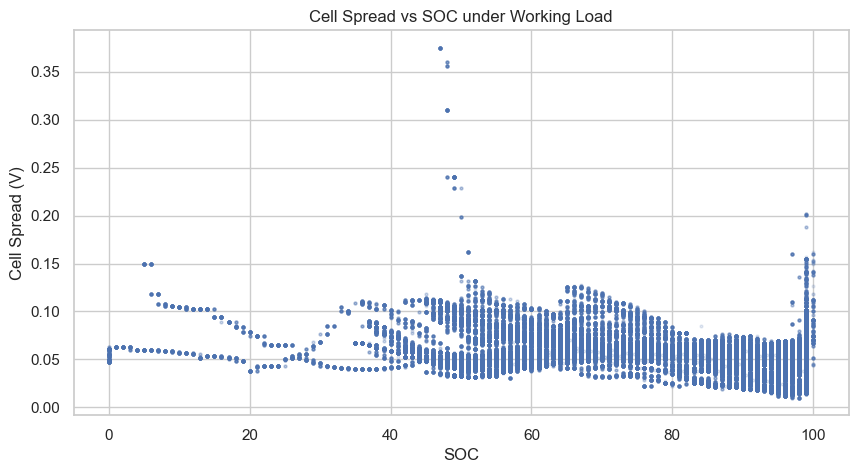

In [47]:
plt.figure(figsize=(10, 5))
plt.scatter(
    working_load["soc"],
    working_load["cell_spread"],
    s=4,
    alpha=0.15
)
plt.title("Cell Spread vs SOC under Working Load")
plt.xlabel("SOC")
plt.ylabel("Cell Spread (V)")
plt.show()

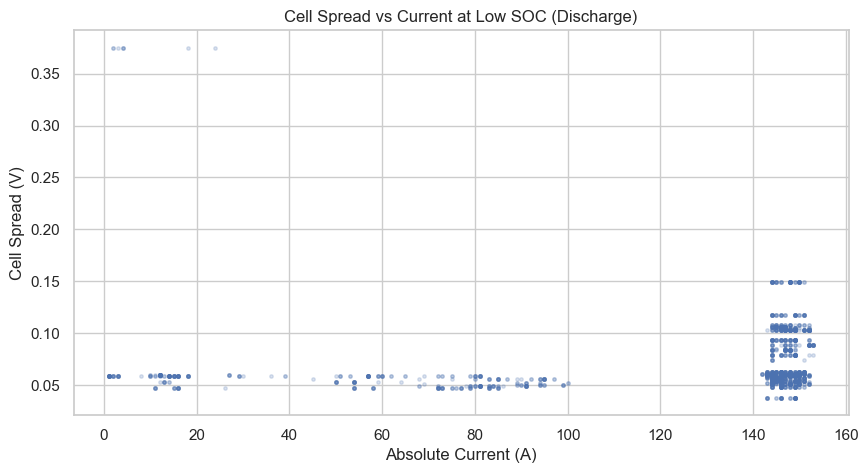

,abs_current,cell_spread,temp_range,pack_v_std
count,1999.000000,1944.000000,1999.000000,1999.000000
mean,126.969985,0.072386,4.560280,0.010309
std,42.522020,0.031326,2.994196,0.002847
min,1.000000,0.038000,1.000000,0.005055
25%,144.000000,0.054000,2.000000,0.009010
50%,146.000000,0.060000,4.000000,0.010084
75%,148.000000,0.089000,7.000000,0.011437
max,153.000000,0.375000,12.000000,0.041258


In [48]:
low_soc_discharge = analysis_phys[
    (analysis_phys["soc"] <= 20) &
    (analysis_phys["current_direction"] == "discharge")
].copy()

plt.figure(figsize=(10, 5))
plt.scatter(
    low_soc_discharge["abs_current"],
    low_soc_discharge["cell_spread"],
    s=6,
    alpha=0.2
)
plt.title("Cell Spread vs Current at Low SOC (Discharge)")
plt.xlabel("Absolute Current (A)")
plt.ylabel("Cell Spread (V)")
plt.show()

display(
    low_soc_discharge[["abs_current", "cell_spread", "temp_range", "pack_v_std"]]
    .describe()
)

In [49]:
trip_features = (
    analysis_phys.assign(
        mod1_hot=analysis_phys["hottest_module"] == 1,
        mod1_low=analysis_phys["lowest_voltage_module"] == 1,
        low_soc=(analysis_phys["soc"] <= 20),
        high_load=(analysis_phys["abs_current"] >= work_current_thr),
        discharge=(analysis_phys["current_direction"] == "discharge")
    )
    .groupby("trip")
    .agg(
        n=("cell_spread", "size"),
        mean_spread=("cell_spread", "mean"),
        p95_spread=("cell_spread", lambda s: s.quantile(0.95)),
        max_spread=("cell_spread", "max"),
        mean_temp_range=("temp_range", "mean"),
        p95_temp_range=("temp_range", lambda s: s.quantile(0.95)),
        mean_abs_current=("abs_current", "mean"),
        pct_low_soc=("low_soc", "mean"),
        pct_high_load=("high_load", "mean"),
        pct_discharge=("discharge", "mean"),
        pct_mod1_hot=("mod1_hot", "mean"),
        pct_mod1_low=("mod1_low", "mean"),
    )
)

for col in ["pct_low_soc", "pct_high_load", "pct_discharge", "pct_mod1_hot", "pct_mod1_low"]:
    trip_features[col] *= 100

display(
    trip_features.sort_values(
        ["p95_spread", "pct_mod1_low", "pct_mod1_hot"],
        ascending=False
    ).head(25)
)

,n,mean_spread,p95_spread,max_spread,mean_temp_range,p95_temp_range,mean_abs_current,pct_low_soc,pct_high_load,pct_discharge,pct_mod1_hot,pct_mod1_low
trip,,,,,,,,,,,,
EV01_000988,4464,0.122678,0.600,0.600,7.755824,11.0,14.073387,0.000000,10.304659,22.379032,64.202509,22.446237
EV01_000894,4149,0.123427,0.240,0.375,2.937816,4.0,35.325217,0.192818,25.162690,99.879489,100.0,82.164377
EV01_000903,591,0.096297,0.170,0.196,8.213198,9.0,41.707192,0.000000,28.595601,87.140440,100.0,99.153976
EV01_001178,8794,0.088621,0.163,0.166,12.637025,17.0,42.307246,0.000000,29.360928,88.605868,63.566068,21.480555
EV01_001266,1420,0.135447,0.159,0.159,11.500704,12.0,1.838505,0.000000,0.000000,36.267606,64.859155,24.225352
EV01_001265,1807,0.086797,0.153,0.155,15.219701,17.0,52.209740,0.000000,51.245158,66.408412,68.622025,19.092418
EV01_001262,3236,0.069933,0.148,0.150,10.989802,12.0,80.817028,0.000000,66.069221,85.228677,88.133498,19.406675
EV01_001181,7618,0.077252,0.140,0.164,6.821869,8.0,34.135259,0.000000,22.985035,83.079548,63.914413,21.265424
EV01_001080,2153,0.069755,0.135,0.201,6.173711,7.0,23.923974,0.000000,28.750581,70.692058,47.979563,99.814213


In [50]:
daily_mod1 = (
    analysis_phys.assign(
        mod1_hot=analysis_phys["hottest_module"] == 1,
        mod1_low=analysis_phys["lowest_voltage_module"] == 1
    )
    .groupby("date")
    .agg(
        pct_mod1_hot=("mod1_hot", "mean"),
        pct_mod1_low=("mod1_low", "mean"),
        mean_spread=("cell_spread", "mean"),
        p95_spread=("cell_spread", lambda s: s.quantile(0.95)),
        mean_temp_range=("temp_range", "mean"),
        mean_abs_current=("abs_current", "mean"),
        n=("cell_spread", "size"),
    )
)

daily_mod1["pct_mod1_hot"] *= 100
daily_mod1["pct_mod1_low"] *= 100

display(daily_mod1.sort_values("pct_mod1_low", ascending=False).head(15))

,pct_mod1_hot,pct_mod1_low,mean_spread,p95_spread,mean_temp_range,mean_abs_current,n
date,,,,,,,
2026-02-24,100.0,100.0,0.069867,0.089,3.123288,10.823256,219
2026-01-28,41.733481,89.894941,0.059049,0.061,13.166851,9.342142,7234
2026-02-02,99.960808,88.869491,0.046664,0.058,5.764207,32.885338,28067
2026-01-29,72.73217,81.178625,0.054564,0.102,7.233301,41.167983,18564
2026-01-31,99.891605,73.455378,0.052502,0.111,7.812357,69.090585,8303
2026-01-23,99.95539,60.981413,0.036893,0.058,35.072565,42.025713,13450
2026-02-08,62.421769,60.0,0.065198,0.140,4.439728,67.072035,3675
2026-02-01,88.321246,58.839645,0.046737,0.064,6.528606,43.844231,18615
2026-01-27,99.992657,58.650316,0.059848,0.103,34.973052,39.385328,13619
